#  Media Recommendation System
### Movies · TV Shows · Anime

This notebook walks through the recommender end-to-end:
1. What is content-based filtering?
2. Building a sample dataset
3. Feature engineering with TF-IDF
4. Computing cosine similarity
5. Making recommendations
6. How to plug in real datasets

> **No downloads needed** — uses a built-in sample of 30 titles so you can run everything right now.

## 1. How Does It Work?

We use **content-based filtering**: recommend titles *similar* to what you've already enjoyed.

```
Attack on Titan  →  [action: 0.8, dark: 0.7, fantasy: 0.5, ...]
Berserk          →  [action: 0.9, dark: 0.9, fantasy: 0.6, ...]
                      ↑ cosine similarity ≈ 0.95  →  strong recommendation!
```

Steps:
- Each title is converted to a **TF-IDF vector** based on genres + overview
- **Cosine similarity** measures how close two vectors are (0 = nothing in common, 1 = identical)
- We aggregate similarity scores across your watched list and rank unseen titles

## 2. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

pd.set_option('display.max_colwidth', 80)
plt.style.use('dark_background')
print('Imports done!')

Imports done!


## 3. Sample Dataset

A curated set of 30 well-known titles. In Section 6 we swap this for real datasets with thousands of titles.

In [2]:
sample_data = [
    # ── Anime ──
    {'title': 'Attack on Titan',               'type': 'Anime',   'genres': 'Action Dark Fantasy Military',          'overview': 'Humanity lives behind walls to protect themselves from giant Titans. A boy swears revenge after his mother is eaten.',                                              'score': 9.0, 'year': 2013},
    {'title': 'Fullmetal Alchemist Brotherhood','type': 'Anime',   'genres': 'Action Adventure Fantasy',             'overview': 'Two brothers use alchemy to restore their bodies, uncovering a vast conspiracy.',                                                                                'score': 9.1, 'year': 2009},
    {'title': 'Death Note',                     'type': 'Anime',   'genres': 'Thriller Mystery Supernatural',        'overview': 'A student finds a supernatural notebook that kills anyone whose name is written in it.',                                                                          'score': 8.9, 'year': 2006},
    {'title': 'Demon Slayer',                   'type': 'Anime',   'genres': 'Action Supernatural Adventure',        'overview': 'A boy becomes a demon slayer after his family is slaughtered and his sister turned into a demon.',                                                                'score': 8.7, 'year': 2019},
    {'title': 'Steins;Gate',                    'type': 'Anime',   'genres': 'Sci-Fi Thriller Time-Travel',          'overview': 'A self-proclaimed mad scientist discovers his microwave can send texts to the past, leading to dangerous consequences.',                                           'score': 9.1, 'year': 2011},
    {'title': 'Jujutsu Kaisen',                 'type': 'Anime',   'genres': 'Action Supernatural Dark Fantasy',     'overview': 'A teenager swallows a cursed object and joins a secret school that fights cursed spirits.',                                                                       'score': 8.6, 'year': 2020},
    {'title': 'Berserk',                        'type': 'Anime',   'genres': 'Action Dark Fantasy Adventure',        'overview': 'A lone mercenary seeks revenge against his former friend who sacrificed their comrades for demonic power.',                                                        'score': 8.7, 'year': 1997},
    {'title': 'Spirited Away',                  'type': 'Anime',   'genres': 'Fantasy Adventure Family',             'overview': 'A girl is trapped in a spirit world and must work in a bathhouse to rescue her parents.',                                                                         'score': 8.6, 'year': 2001},
    {'title': 'Your Name',                      'type': 'Anime',   'genres': 'Romance Fantasy Drama',                'overview': 'Two teenagers mysteriously swap bodies, forming a deep connection across time and space.',                                                                         'score': 8.4, 'year': 2016},
    {'title': 'Hunter x Hunter',                'type': 'Anime',   'genres': 'Action Adventure Fantasy',             'overview': 'A boy sets out to become a Hunter and find his father, encountering incredible challenges.',                                                                       'score': 9.0, 'year': 2011},
    # ── TV Shows ──
    {'title': 'Arcane',                         'type': 'TV Show', 'genres': 'Action Fantasy Sci-Fi Dark',           'overview': 'Two sisters find themselves on opposing sides of a war between utopia and the slums below.',                                                                        'score': 9.0, 'year': 2021},
    {'title': 'Breaking Bad',                   'type': 'TV Show', 'genres': 'Crime Thriller Drama',                 'overview': 'A chemistry teacher with cancer turns to manufacturing methamphetamine to secure his family s future.',                                                             'score': 9.5, 'year': 2008},
    {'title': 'Stranger Things',                'type': 'TV Show', 'genres': 'Sci-Fi Horror Thriller Mystery',       'overview': 'Kids encounter supernatural forces and secret government experiments in their small town.',                                                                          'score': 8.7, 'year': 2016},
    {'title': 'The Last of Us',                 'type': 'TV Show', 'genres': 'Drama Thriller Post-Apocalyptic',      'overview': 'A hardened survivor smuggles a teen who may be humanity s last hope across post-pandemic America.',                                                                 'score': 8.8, 'year': 2023},
    {'title': 'Black Mirror',                   'type': 'TV Show', 'genres': 'Sci-Fi Thriller Anthology',            'overview': 'An anthology series exploring dark tales about technology and modern society.',                                                                                     'score': 8.8, 'year': 2011},
    {'title': 'Game of Thrones',                'type': 'TV Show', 'genres': 'Fantasy Drama Action',                 'overview': 'Noble families fight for the Iron Throne while an ancient enemy threatens from beyond a massive wall.',                                                             'score': 9.2, 'year': 2011},
    {'title': 'The Witcher',                    'type': 'TV Show', 'genres': 'Fantasy Action Adventure',             'overview': 'A mutated monster-hunter struggles to find his place in a world where people are often more wicked than beasts.',                                                   'score': 8.2, 'year': 2019},
    {'title': 'Dark',                           'type': 'TV Show', 'genres': 'Sci-Fi Mystery Thriller',              'overview': 'In a German town, the disappearance of children reveals a time travel conspiracy spanning generations.',                                                              'score': 8.8, 'year': 2017},
    # ── Movies ──
    {'title': 'Inception',                      'type': 'Movie',   'genres': 'Sci-Fi Thriller Action',               'overview': 'A thief who steals secrets through dream-sharing is given the task of planting an idea in a target s mind.',                                                       'score': 8.8, 'year': 2010},
    {'title': 'The Dark Knight',                'type': 'Movie',   'genres': 'Action Crime Thriller',                'overview': 'Batman faces the Joker, a criminal mastermind who wants to plunge Gotham City into anarchy.',                                                                      'score': 9.0, 'year': 2008},
    {'title': 'Interstellar',                   'type': 'Movie',   'genres': 'Sci-Fi Drama Adventure',               'overview': 'Explorers travel through a wormhole in space in an attempt to ensure humanity s survival.',                                                                        'score': 8.6, 'year': 2014},
    {'title': 'The Matrix',                     'type': 'Movie',   'genres': 'Sci-Fi Action Thriller',               'overview': 'A hacker discovers reality is a simulation and joins a rebellion against its machine overlords.',                                                                   'score': 8.7, 'year': 1999},
    {'title': 'Parasite',                       'type': 'Movie',   'genres': 'Thriller Drama Dark Comedy',           'overview': 'A poor family schemes to become employed by a wealthy family and infiltrates their household.',                                                                     'score': 8.5, 'year': 2019},
    {'title': 'Get Out',                        'type': 'Movie',   'genres': 'Horror Thriller Mystery',              'overview': 'A Black man visits his white girlfriend s family estate and uncovers a dark secret.',                                                                               'score': 7.7, 'year': 2017},
    {'title': 'Everything Everywhere All at Once','type': 'Movie', 'genres': 'Sci-Fi Comedy Drama Action',           'overview': 'A Chinese-American woman must connect with alternate universe versions of herself to save reality.',                                                                 'score': 7.8, 'year': 2022},
    {'title': 'Dune',                           'type': 'Movie',   'genres': 'Sci-Fi Adventure Drama',               'overview': 'A noble family becomes embroiled in a war for control over a desert planet and its powerful spice.',                                                                'score': 8.0, 'year': 2021},
    {'title': 'The Batman',                     'type': 'Movie',   'genres': 'Action Crime Thriller Mystery',        'overview': 'Batman ventures into Gotham s underworld when a sadistic killer leaves behind cryptic clues.',                                                                      'score': 7.8, 'year': 2022},
    {'title': 'Hereditary',                     'type': 'Movie',   'genres': 'Horror Drama Thriller',                'overview': 'A family unravels terrifying secrets about their ancestry after the death of their reclusive grandmother.',                                                         'score': 7.3, 'year': 2018},
    {'title': 'Midsommar',                      'type': 'Movie',   'genres': 'Horror Mystery Thriller',              'overview': 'A couple travels to Sweden to attend a midsummer festival that slowly devolves into something sinister.',                                                            'score': 7.1, 'year': 2019},
    {'title': 'Knives Out',                     'type': 'Movie',   'genres': 'Mystery Thriller Comedy Crime',        'overview': 'A detective investigates the death of a patriarch of an eccentric, combative family.',                                                                              'score': 7.9, 'year': 2019},
]

df = pd.DataFrame(sample_data)
print(f'Loaded {len(df)} titles')
df.head(10)

Loaded 30 titles


,title,type,genres,overview,score,year
0,Attack on Titan,Anime,Action Dark Fantasy Military,Humanity lives behind walls to protect themselves from giant Titans. A boy s...,9.0,2013
1,Fullmetal Alchemist Brotherhood,Anime,Action Adventure Fantasy,"Two brothers use alchemy to restore their bodies, uncovering a vast conspiracy.",9.1,2009
2,Death Note,Anime,Thriller Mystery Supernatural,A student finds a supernatural notebook that kills anyone whose name is writ...,8.9,2006
3,Demon Slayer,Anime,Action Supernatural Adventure,A boy becomes a demon slayer after his family is slaughtered and his sister ...,8.7,2019
4,Steins;Gate,Anime,Sci-Fi Thriller Time-Travel,A self-proclaimed mad scientist discovers his microwave can send texts to th...,9.1,2011
5,Jujutsu Kaisen,Anime,Action Supernatural Dark Fantasy,A teenager swallows a cursed object and joins a secret school that fights cu...,8.6,2020
6,Berserk,Anime,Action Dark Fantasy Adventure,A lone mercenary seeks revenge against his former friend who sacrificed thei...,8.7,1997
7,Spirited Away,Anime,Fantasy Adventure Family,A girl is trapped in a spirit world and must work in a bathhouse to rescue h...,8.6,2001
8,Your Name,Anime,Romance Fantasy Drama,"Two teenagers mysteriously swap bodies, forming a deep connection across tim...",8.4,2016
9,Hunter x Hunter,Anime,Action Adventure Fantasy,"A boy sets out to become a Hunter and find his father, encountering incredib...",9.0,2011


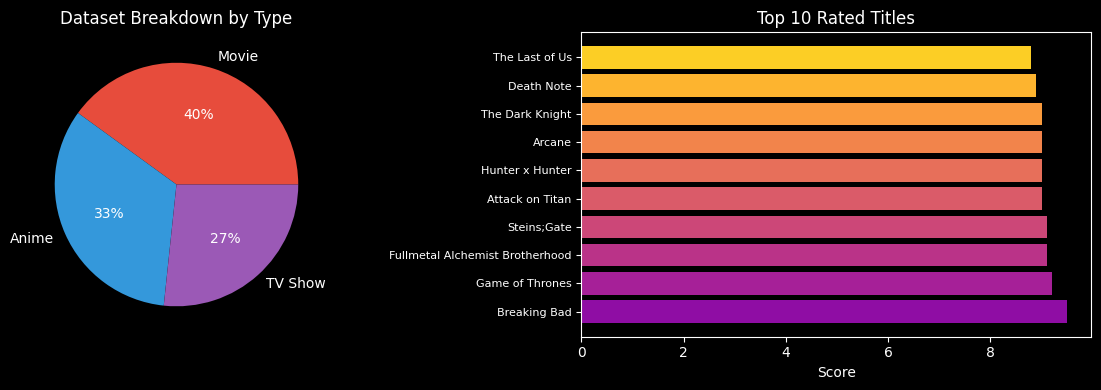

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

type_counts = df['type'].value_counts()
axes[0].pie(type_counts, labels=type_counts.index, autopct='%1.0f%%',
            colors=['#e74c3c', '#3498db', '#9b59b6'])
axes[0].set_title('Dataset Breakdown by Type')

top10 = df.nlargest(10, 'score')
axes[1].barh(top10['title'], top10['score'],
             color=cm.plasma(np.linspace(0.3, 0.9, 10)))
axes[1].set_xlabel('Score')
axes[1].set_title('Top 10 Rated Titles')
axes[1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

## 4. Feature Engineering — TF-IDF

We combine each title's genres (repeated 3× for extra weight) and overview into a text blob, then run **TF-IDF** over it.

- **TF** = how often a word appears in *this* title
- **IDF** = penalises common words that appear everywhere
- Result: genre words like `action` or `dark` become meaningful signals

In [4]:
df['soup'] = (
    (df['genres'] + ' ') * 3   # genres weighted 3x
    + df['overview'].str[:300]  # first 300 chars of overview
    + ' ' + df['type']          # type as a weak signal
)

print('Sample soup for Attack on Titan:')
print(df[df['title'] == 'Attack on Titan']['soup'].values[0])

Sample soup for Attack on Titan:
Action Dark Fantasy Military Action Dark Fantasy Military Action Dark Fantasy Military Humanity lives behind walls to protect themselves from giant Titans. A boy swears revenge after his mother is eaten. Anime


In [5]:
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['soup'])

print(f'TF-IDF matrix shape: {tfidf_matrix.shape}')
print(f'  {tfidf_matrix.shape[0]} titles x {tfidf_matrix.shape[1]} unique words')

TF-IDF matrix shape: (30, 246)
  30 titles x 246 unique words


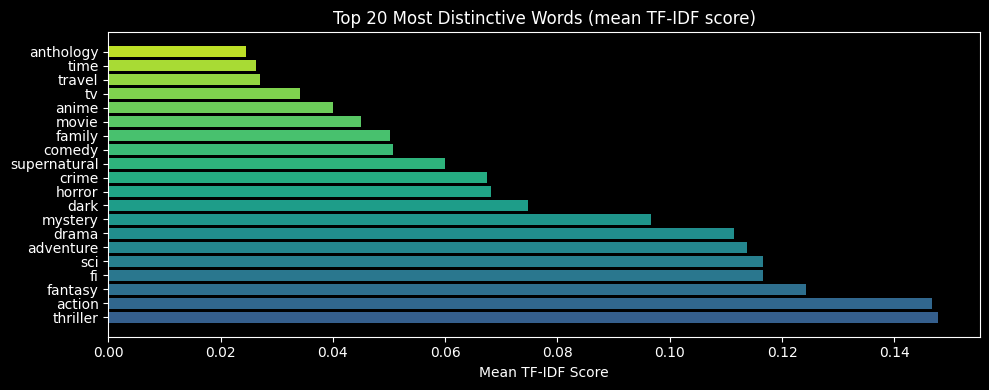

In [6]:
feature_names = tfidf.get_feature_names_out()
dense = tfidf_matrix.toarray()
top_features = pd.DataFrame({
    'word': feature_names,
    'mean_tfidf': dense.mean(axis=0)
}).sort_values('mean_tfidf', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(top_features['word'], top_features['mean_tfidf'],
        color=cm.viridis(np.linspace(0.3, 0.9, 20)))
ax.set_title('Top 20 Most Distinctive Words (mean TF-IDF score)')
ax.set_xlabel('Mean TF-IDF Score')
plt.tight_layout()
plt.show()

## 5. Cosine Similarity

Now we compute how similar every pair of titles is to every other.

In [7]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print(f'Similarity matrix shape: {cosine_sim.shape}')

indices = pd.Series(df.index, index=df['title'].str.lower())

idx = indices['attack on titan']
sim_scores = sorted(enumerate(cosine_sim[idx]), key=lambda x: x[1], reverse=True)
sim_df = pd.DataFrame(
    [(df.iloc[i]['title'], df.iloc[i]['type'], round(s, 3)) for i, s in sim_scores[1:6]],
    columns=['title', 'type', 'similarity']
)
print('Most similar titles to Attack on Titan:')
sim_df

Similarity matrix shape: (30, 30)
Most similar titles to Attack on Titan:


,title,type,similarity
0,Berserk,Anime,0.389
1,Arcane,TV Show,0.350
2,Jujutsu Kaisen,Anime,0.321
3,Hunter x Hunter,Anime,0.277
4,Fullmetal Alchemist Brotherhood,Anime,0.235


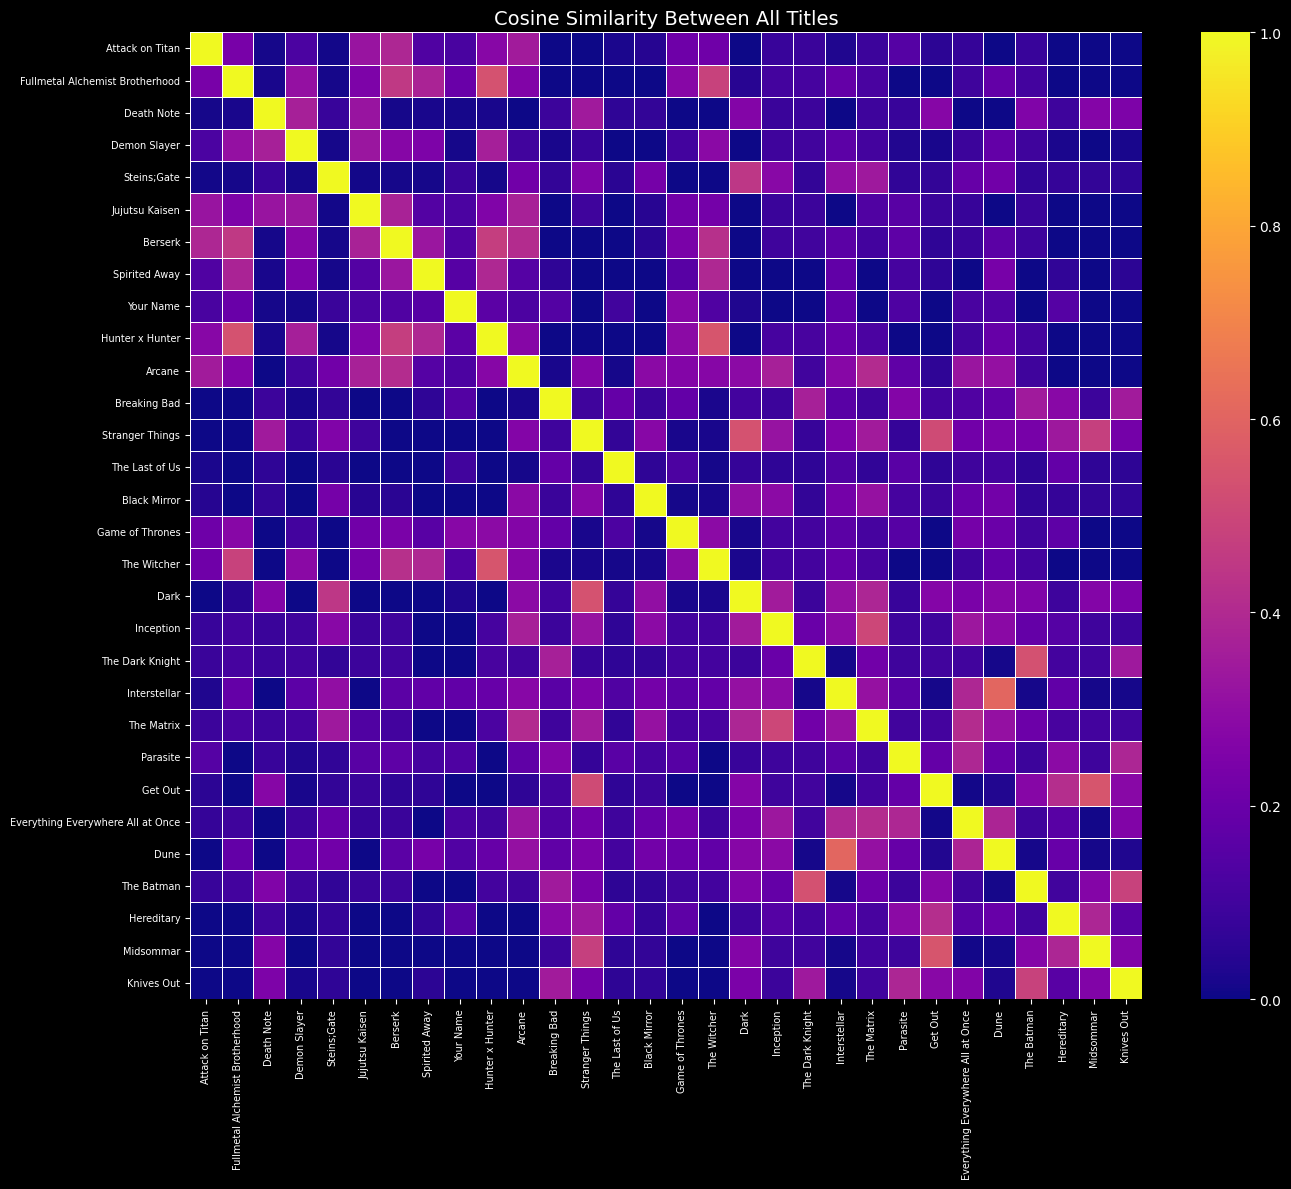

In [8]:
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cosine_sim,
    xticklabels=df['title'],
    yticklabels=df['title'],
    cmap='plasma',
    ax=ax,
    linewidths=0.5,
)
ax.set_title('Cosine Similarity Between All Titles', fontsize=14)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

## 6. The Recommender in Action

In [9]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))  # make sure recommender.py is found

from recommender import MediaRecommender
from sklearn.preprocessing import MinMaxScaler

df['score_norm'] = MinMaxScaler().fit_transform(df[['score']])

rec = MediaRecommender()
rec.fit(df)
print('Recommender ready!')

Building TF-IDF similarity matrix …
Done. 30 titles indexed.
Recommender ready!


In [10]:
# Example 1 — dark action fan
print('=== Example 1: Dark Action Fan ===')
recs = rec.recommend(
    watched=['Attack on Titan', 'Arcane'],
    ratings={'Attack on Titan': 10, 'Arcane': 9},
    n=5,
)
recs

=== Example 1: Dark Action Fan ===


,title,type,genres,score,year,final_score
0,Berserk,Anime,Action Dark Fantasy Adventure,8.7,1997,0.732884
1,Jujutsu Kaisen,Anime,Action Supernatural Dark Fantasy,8.6,2020,0.645397
2,Hunter x Hunter,Anime,Action Adventure Fantasy,9.0,2011,0.588395
3,Fullmetal Alchemist Brotherhood,Anime,Action Adventure Fantasy,9.1,2009,0.560529
4,Game of Thrones,TV Show,Fantasy Drama Action,9.2,2011,0.553604


In [11]:
# Example 2 — sci-fi / thriller lover
print('=== Example 2: Sci-Fi Thriller Fan ===')
recs2 = rec.recommend(
    watched=['Inception', 'Black Mirror', 'Steins;Gate'],
    ratings={'Inception': 9, 'Black Mirror': 8, 'Steins;Gate': 10},
    n=5,
)
recs2

=== Example 2: Sci-Fi Thriller Fan ===


,title,type,genres,score,year,final_score
0,The Matrix,Movie,Sci-Fi Action Thriller,8.7,1999,0.953134
1,Dark,TV Show,Sci-Fi Mystery Thriller,8.8,2017,0.927046
2,Arcane,TV Show,Action Fantasy Sci-Fi Dark,9.0,2021,0.778071
3,Stranger Things,TV Show,Sci-Fi Horror Thriller Mystery,8.7,2016,0.737990
4,Interstellar,Movie,Sci-Fi Drama Adventure,8.6,2014,0.712983


In [12]:
# Example 3 — horror fan, movies only
print('=== Example 3: Horror Fan — Movies Only ===')
recs3 = rec.recommend(
    watched=['Hereditary', 'Get Out'],
    ratings={'Hereditary': 9, 'Get Out': 8},
    n=5,
    filter_type='Movie',
)
recs3

=== Example 3: Horror Fan — Movies Only ===


,title,type,genres,score,year,final_score
0,Midsommar,Movie,Horror Mystery Thriller,7.1,2019,0.590075
1,Parasite,Movie,Thriller Drama Dark Comedy,8.5,2019,0.452582
2,Knives Out,Movie,Mystery Thriller Comedy Crime,7.9,2019,0.356447
3,Inception,Movie,Sci-Fi Thriller Action,8.8,2010,0.334574
4,The Dark Knight,Movie,Action Crime Thriller,9.0,2008,0.330952


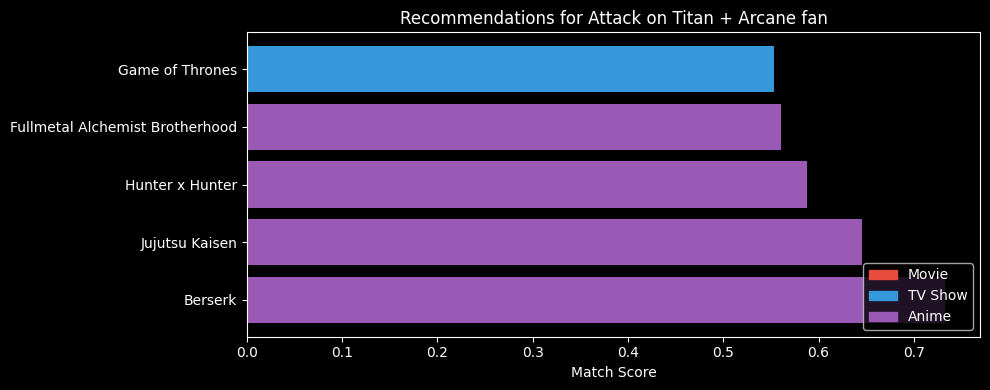

In [13]:
# Visualise match scores
from matplotlib.patches import Patch

colors = {'Movie': '#e74c3c', 'TV Show': '#3498db', 'Anime': '#9b59b6'}
bar_colors = [colors.get(t, '#95a5a6') for t in recs['type']]

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(recs['title'], recs['final_score'], color=bar_colors)
ax.set_xlabel('Match Score')
ax.set_title('Recommendations for Attack on Titan + Arcane fan')
legend = [Patch(color=c, label=t) for t, c in colors.items()]
ax.legend(handles=legend, loc='lower right')
plt.tight_layout()
plt.show()

## 7. Using Real Datasets

Download these free CSVs and place them in your `data/` folder:

| File | Source |
|------|--------|
| `data/movies.csv` | [TMDB Movies on Kaggle](https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata) |
| `data/shows.csv`  | [TMDB TV Shows on Kaggle](https://www.kaggle.com/datasets/asaniczka/full-tmdb-tv-shows-dataset-2023) |
| `data/anime.csv`  | [MyAnimeList on Kaggle](https://www.kaggle.com/datasets/CooperUnion/anime-recommendations-database) |

Then run:
```python
from recommender import load_data, MediaRecommender

df = load_data()
rec = MediaRecommender()
rec.fit(df)

recs = rec.recommend(
    watched=['Attack on Titan', 'Breaking Bad', 'Inception'],
    ratings={'Attack on Titan': 10, 'Breaking Bad': 9, 'Inception': 9},
    n=10,
)
```

Or launch the Streamlit app:
```bash
streamlit run app.py
```

## 8. What This Project Built & What's Next

###  What we built

| Component | Approach | Status |
|-----------|----------|--------|
| Content-based recommender | TF-IDF + cosine similarity on genres & overviews |  Done |
| Neural Collaborative Filtering | PyTorch NCF with GMF + MLP paths, trained on 10M+ ratings |  Done |
| Cross-media support | Movies, TV shows, and anime in one unified system |  Done |
| Cold-start handling | Content-based kicks in when neural has no signal |  Done |
| Streamlit UI | Search, rate titles, get recommendations with match % |  Done |

###  Current Limitations

- **Genre bubbles** — content-based can over-recommend within a single genre
- **Cold-start for neural model** — new users get pseudo-embeddings which are less accurate than trained ones
- **No live metadata** — posters, descriptions pulled from static CSVs not a live API
- **User IDs not persisted** — the app doesn't remember you between sessions

###  Ideas to take it further

- **TMDB API integration** — pull live posters, trailers, and up-to-date metadata
- **Sentence-BERT embeddings** — replace TF-IDF with a pretrained language model for richer semantic similarity
- **User accounts** — save watch history and ratings to a database between sessions
- **Feedback loop** — let users mark results as 'not interested' to refine future recommendations
- **Sequence-aware model** — use a Transformer to model *order* of watching, not just what you watched

---
# Part 2: Neural Collaborative Filtering (NCF)

Now we go deeper — a **PyTorch neural network** that learns user and item embeddings from real rating data.

## Why Neural over TF-IDF?

| | Content-Based (TF-IDF) | Neural CF |
|---|---|---|
| Data needed | Just metadata (genres, overview) | User rating history |
| Learns from behaviour | No | Yes |
| Catches non-obvious patterns | No | Yes |
| Cold start (new users) | Works fine | Harder |
| Explainability | High | Lower |

Both approaches have strengths — the best real-world systems combine them (called a **hybrid recommender**).

## The Architecture

```
User ID --> User Embedding (64d) ──┐
                                    ├─(GMF)─► element-wise product ──┐
Item ID --> Item Embedding (64d) ──┘                                 ├--> Linear --> Rating
                                    ├─(MLP)─► [128 → 64 → 32] ──────┘
User ID --> User Embedding (64d) ──┤
                                    │
Item ID --> Item Embedding (64d) ──┘
```

- **GMF** (Generalised Matrix Factorisation): captures linear user-item interactions
- **MLP**: captures non-linear patterns — e.g. a user who loves anime action but hates anime romance
- Both paths are merged → final predicted rating

## Setup — Import the Neural Recommender

In [14]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.model_selection import train_test_split

from neural_recommender import NCF, Config, RatingsDataset, encode_and_normalise, load_ratings, train
from torch.utils.data import DataLoader

print(f'PyTorch version: {torch.__version__}')
print(f'Device: {"GPU (cuda)" if torch.cuda.is_available() else "CPU"}')

PyTorch version: 2.10.0+cu130
Device: GPU (cuda)


## Simulated Training Demo

Below we simulate training on synthetic rating data so this notebook runs without downloading anything.
The real training loop is identical — swap in real data in the last section.

> **To train on real data**, skip to the *Real Data Training* section at the bottom.

In [15]:
# ── Generate synthetic ratings ──
np.random.seed(42)
N_USERS, N_ITEMS, N_RATINGS = 500, 200, 8000

# Simulate 5 latent 'taste clusters' so the model has real patterns to learn
user_clusters = np.random.randint(0, 5, N_USERS)
item_clusters = np.random.randint(0, 5, N_ITEMS)

users   = np.random.randint(0, N_USERS, N_RATINGS)
items   = np.random.randint(0, N_ITEMS, N_RATINGS)
# Users rate items in their cluster higher
base    = (user_clusters[users] == item_clusters[items]).astype(float) * 4
ratings = np.clip(base + np.random.normal(5, 1.5, N_RATINGS), 1, 10)

synth_df = pd.DataFrame({'user_idx': users, 'item_idx': items, 'rating_norm': (ratings - 1) / 9})

print(f'Synthetic dataset: {len(synth_df):,} ratings')
print(f'Rating distribution:\n{pd.cut(ratings, bins=5).value_counts().sort_index()}')

Synthetic dataset: 8,000 ratings
Rating distribution:
(0.991, 2.8]     471
(2.8, 4.6]      2002
(4.6, 6.4]      2925
(6.4, 8.2]      1452
(8.2, 10.0]     1150
Name: count, dtype: int64


In [16]:
# ── Build model ──
cfg = Config()
cfg.EPOCHS       = 15
cfg.EMBEDDING_DIM = 32
cfg.MLP_LAYERS   = [64, 32, 16]
cfg.BATCH_SIZE   = 256

model = NCF(N_USERS, N_ITEMS, cfg)
total_params = sum(p.numel() for p in model.parameters())
print(f'Model architecture:')
print(model)
print(f'\nTotal trainable parameters: {total_params:,}')

Model architecture:
NCF(
  (user_emb_gmf): Embedding(500, 32)
  (item_emb_gmf): Embedding(200, 32)
  (user_emb_mlp): Embedding(500, 32)
  (item_emb_mlp): Embedding(200, 32)
  (mlp): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
  )
  (output): Linear(in_features=48, out_features=1, bias=True)
)

Total trainable parameters: 51,617


In [17]:
# ── Training loop (simulated data) ──
train_df, val_df = train_test_split(synth_df, test_size=0.1, random_state=42)

train_ds = RatingsDataset(train_df['user_idx'].values, train_df['item_idx'].values, train_df['rating_norm'].values)
val_ds   = RatingsDataset(val_df['user_idx'].values,   val_df['item_idx'].values,   val_df['rating_norm'].values)

train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=cfg.BATCH_SIZE, shuffle=False)

criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

history = {'train_loss': [], 'val_loss': []}

for epoch in range(1, cfg.EPOCHS + 1):
    # Train
    model.train()
    t_loss = 0
    for u, i, r in train_loader:
        optimizer.zero_grad()
        pred = model(u, i)
        loss = criterion(pred, r)
        loss.backward()
        optimizer.step()
        t_loss += loss.item() * len(r)
    t_loss /= len(train_ds)

    # Validate
    model.eval()
    v_loss = 0
    with torch.no_grad():
        for u, i, r in val_loader:
            pred = model(u, i)
            v_loss += criterion(pred, r).item() * len(r)
    v_loss /= len(val_ds)

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    print(f'Epoch {epoch:>2}/{cfg.EPOCHS}  train={t_loss:.4f}  val={v_loss:.4f}')

Epoch  1/15  train=0.0532  val=0.0497
Epoch  2/15  train=0.0524  val=0.0495
Epoch  3/15  train=0.0521  val=0.0496
Epoch  4/15  train=0.0513  val=0.0499
Epoch  5/15  train=0.0498  val=0.0514
Epoch  6/15  train=0.0482  val=0.0524
Epoch  7/15  train=0.0467  val=0.0529
Epoch  8/15  train=0.0447  val=0.0534
Epoch  9/15  train=0.0423  val=0.0528
Epoch 10/15  train=0.0394  val=0.0527
Epoch 11/15  train=0.0359  val=0.0526
Epoch 12/15  train=0.0325  val=0.0516
Epoch 13/15  train=0.0285  val=0.0515
Epoch 14/15  train=0.0249  val=0.0507
Epoch 15/15  train=0.0214  val=0.0510


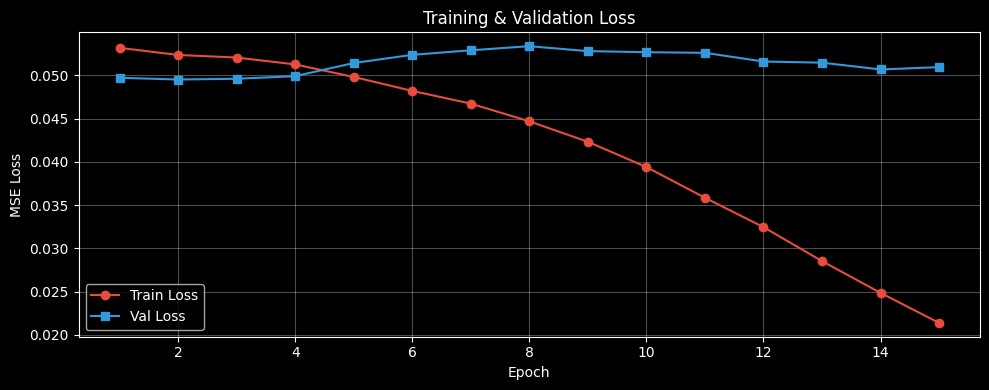

Final train loss: 0.0214
Final val loss:   0.0510


In [18]:
# ── Plot loss curves ──
fig, ax = plt.subplots(figsize=(10, 4))
epochs = range(1, len(history['train_loss']) + 1)
ax.plot(epochs, history['train_loss'], 'o-', label='Train Loss', color='#e74c3c')
ax.plot(epochs, history['val_loss'],   's-', label='Val Loss',   color='#3498db')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Final train loss: {history["train_loss"][-1]:.4f}')
print(f'Final val loss:   {history["val_loss"][-1]:.4f}')

## Visualising the Learned Embeddings

One of the most insightful things you can do with a trained NCF model is **visualise the item embeddings**.
Items that end up close together in embedding space are ones the model has learned are similar.

We reduce the 32-dimensional embeddings to 2D using **PCA** (or UMAP if installed).

Item embedding matrix: (200, 32)
Variance explained by 2 PCs: 72.7%


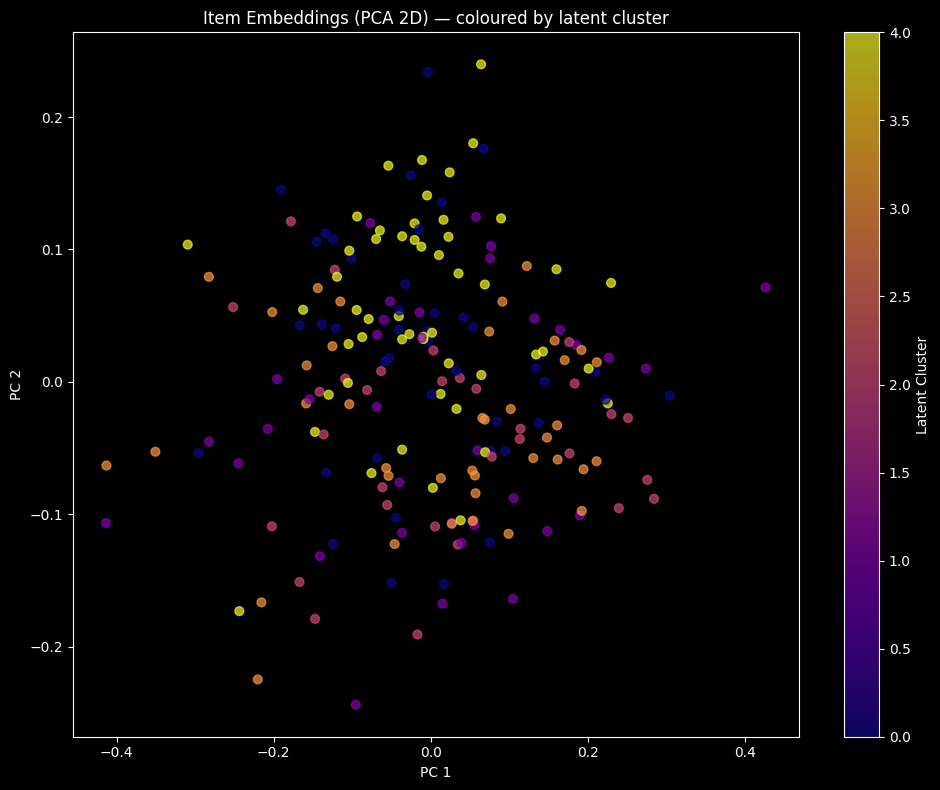

Items from the same cluster should appear close together if the model learned the pattern.


In [19]:
from sklearn.decomposition import PCA

# Extract item embeddings from the MLP path
with torch.no_grad():
    all_item_ids = torch.arange(N_ITEMS)
    item_embs = model.item_emb_mlp(all_item_ids).numpy()   # (N_ITEMS, 32)

# Reduce to 2D with PCA
pca = PCA(n_components=2, random_state=42)
embs_2d = pca.fit_transform(item_embs)

print(f'Item embedding matrix: {item_embs.shape}')
print(f'Variance explained by 2 PCs: {pca.explained_variance_ratio_.sum():.1%}')

# Plot — colour by latent cluster
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    embs_2d[:, 0], embs_2d[:, 1],
    c=item_clusters, cmap='plasma',
    alpha=0.7, s=40
)
plt.colorbar(scatter, ax=ax, label='Latent Cluster')
ax.set_title('Item Embeddings (PCA 2D) — coloured by latent cluster')
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
plt.tight_layout()
plt.show()
print('Items from the same cluster should appear close together if the model learned the pattern.')

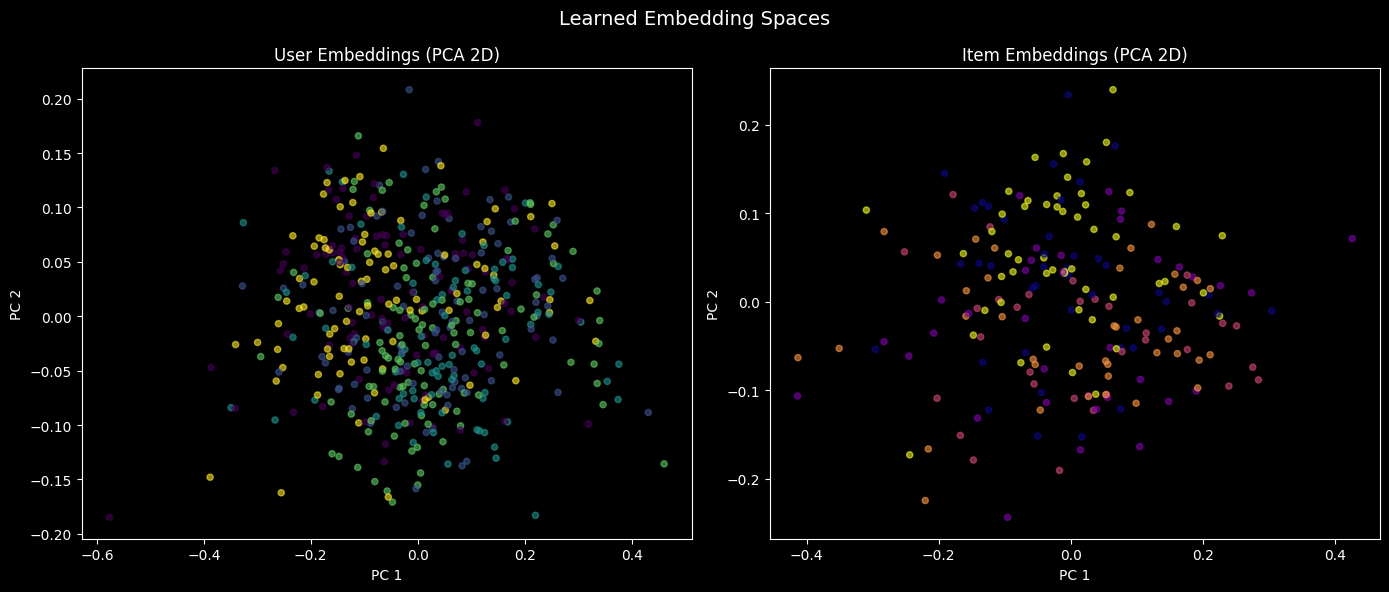

In [20]:
# ── Also visualise user embeddings ──
with torch.no_grad():
    all_user_ids = torch.arange(N_USERS)
    user_embs = model.user_emb_mlp(all_user_ids).numpy()

user_embs_2d = pca.fit_transform(user_embs)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(user_embs_2d[:, 0], user_embs_2d[:, 1],
               c=user_clusters, cmap='viridis', alpha=0.6, s=20)
axes[0].set_title('User Embeddings (PCA 2D)')
axes[0].set_xlabel('PC 1'); axes[0].set_ylabel('PC 2')

embs_2d_items = PCA(n_components=2, random_state=42).fit_transform(item_embs)
axes[1].scatter(embs_2d_items[:, 0], embs_2d_items[:, 1],
               c=item_clusters, cmap='plasma', alpha=0.6, s=20)
axes[1].set_title('Item Embeddings (PCA 2D)')
axes[1].set_xlabel('PC 1'); axes[1].set_ylabel('PC 2')

plt.suptitle('Learned Embedding Spaces', fontsize=14)
plt.tight_layout()
plt.show()

## Real Data Training

To train on real data:

**1. Download the datasets** (free, just need a Kaggle account):
- [MyAnimeList ratings](https://www.kaggle.com/datasets/CooperUnion/anime-recommendations-database) → save as `data/ratings.csv` and `data/anime.csv`
- Or [MovieLens 1M](https://grouplens.org/datasets/movielens/) → save as `data/ratings.csv`

**2. Run from terminal** (recommended — training can take a few minutes):
```bash
python neural_recommender.py
```

**3. Or run right here in the notebook:**

In [21]:
# Uncomment and run once you have data/ratings.csv

# from neural_recommender import train, Config
#
# cfg = Config()
# cfg.EPOCHS = 20
#
# model, encoders, history = train(cfg)
# print('Training complete!')

## Loading the Trained Model for Recommendations

After training, the model is saved to `models/ncf_model.pt`. Load it like this:

```python
from neural_recommender import NeuralRecommender
import pandas as pd

rec = NeuralRecommender.load('models/ncf_model.pt')

# For a cold-start user — just give it some ratings:
anime_df = pd.read_csv('data/anime.csv')
anime_df = anime_df.rename(columns={'name': 'title', 'anime_id': 'item_id', 'genre': 'genres', 'rating': 'score'})

recs = rec.recommend_from_ratings(
    title_ratings={
        'Attack on Titan': 10,
        'Death Note': 9,
        'Fullmetal Alchemist Brotherhood': 10,
    },
    item_df=anime_df,
    n=10,
)
print(recs)
```

## Hybrid Approach (Best of Both Worlds)

The `app.py` Streamlit UI can blend the neural model with the content-based one:
```python
# Blend scores 50/50
final_score = 0.5 * neural_score + 0.5 * content_score
```

This gives you:
- Neural model's behavioural patterns (people like you watched X)
- Content model's genre/description similarity
- Better cold-start handling (content kicks in when neural has no signal)